In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 全局设置（中文+样式）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

In [3]:
file_path = r'ecommerce_orders.csv'

df = pd.read_csv(
    file_path,
    encoding='utf-8',
    parse_dates=['下单时间', '支付时间']
)

df

,订单号,下单时间,支付时间,商品名称,品类,单价(元),数量,支付金额(元),退款金额(元),城市,用户ID
0,ORD001,2024-05-01 08:30:00,2024-05-01 08:35:00,智能手机,数码,2999,1,2999,0.0,北京,U001
1,ORD002,2024-05-01 09:10:00,2024-05-02 09:12:00,无线耳机,数码,199,1,199,0.0,上海,U002
2,ORD003,2024-05-01 10:00:00,NaT,纯棉卫衣,服饰,159,2,318,0.0,广州,U003
3,ORD004,2024-05-02 11:20:00,2024-05-02 11:25:00,智能水杯,家居,99,1,99,99.0,深圳,U004
4,ORD005,2024-05-02 14:00:00,2024-05-02 14:08:00,机械键盘,数码,299,1,299,0.0,北京,U005
5,ORD006,2024-05-03 09:00:00,2024-05-03 09:10:00,运动跑鞋,服饰,399,1,399,0.0,上海,U006
6,ORD007,2024-05-03 15:30:00,2024-05-03 15:35:00,厨房刀具,家居,129,1,129,0.0,广州,U007
7,ORD008,2024-05-04 10:20:00,2024-05-04 10:22:00,平板电脑,数码,1999,1,1999,0.0,深圳,U008
8,ORD009,2024-05-04 16:40:00,NaT,休闲裤,服饰,89,2,178,0.0,北京,U009
9,ORD010,2024-05-05 11:00:00,2024-05-05 11:05:00,电饭煲,家居,299,1,299,149.5,上海,U010


In [4]:
df.shape

(10, 11)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 11 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   订单号      10 non-null     str           
 1   下单时间     10 non-null     datetime64[us]
 2   支付时间     8 non-null      datetime64[us]
 3   商品名称     10 non-null     str           
 4   品类       10 non-null     str           
 5   单价(元)    10 non-null     int64         
 6   数量       10 non-null     int64         
 7   支付金额(元)  10 non-null     int64         
 8   退款金额(元)  10 non-null     float64       
 9   城市       10 non-null     str           
 10  用户ID     10 non-null     str           
dtypes: datetime64[us](2), float64(1), int64(3), str(5)
memory usage: 1012.0 bytes


In [6]:
df.isnull().sum()

订单号        0
下单时间       0
支付时间       2
商品名称       0
品类         0
单价(元)      0
数量         0
支付金额(元)    0
退款金额(元)    0
城市         0
用户ID       0
dtype: int64

In [7]:
df[['单价(元)', '数量', '支付金额(元)']].describe()

,单价(元),数量,支付金额(元)
count,10.000000,10.000000,10.00000
mean,667.000000,1.200000,691.80000
std,998.797054,0.421637,985.50515
min,89.000000,1.000000,99.00000
25%,136.500000,1.000000,183.25000
50%,249.000000,1.000000,299.00000
75%,374.000000,1.000000,378.75000
max,2999.000000,2.000000,2999.00000


In [8]:
df

,订单号,下单时间,支付时间,商品名称,品类,单价(元),数量,支付金额(元),退款金额(元),城市,用户ID
0,ORD001,2024-05-01 08:30:00,2024-05-01 08:35:00,智能手机,数码,2999,1,2999,0.0,北京,U001
1,ORD002,2024-05-01 09:10:00,2024-05-02 09:12:00,无线耳机,数码,199,1,199,0.0,上海,U002
2,ORD003,2024-05-01 10:00:00,NaT,纯棉卫衣,服饰,159,2,318,0.0,广州,U003
3,ORD004,2024-05-02 11:20:00,2024-05-02 11:25:00,智能水杯,家居,99,1,99,99.0,深圳,U004
4,ORD005,2024-05-02 14:00:00,2024-05-02 14:08:00,机械键盘,数码,299,1,299,0.0,北京,U005
5,ORD006,2024-05-03 09:00:00,2024-05-03 09:10:00,运动跑鞋,服饰,399,1,399,0.0,上海,U006
6,ORD007,2024-05-03 15:30:00,2024-05-03 15:35:00,厨房刀具,家居,129,1,129,0.0,广州,U007
7,ORD008,2024-05-04 10:20:00,2024-05-04 10:22:00,平板电脑,数码,1999,1,1999,0.0,深圳,U008
8,ORD009,2024-05-04 16:40:00,NaT,休闲裤,服饰,89,2,178,0.0,北京,U009
9,ORD010,2024-05-05 11:00:00,2024-05-05 11:05:00,电饭煲,家居,299,1,299,149.5,上海,U010


In [9]:
df['支付状态'] = df['支付时间'].apply(lambda x: '已支付' if pd.notna(x) else '未支付')
df

,订单号,下单时间,支付时间,商品名称,品类,单价(元),数量,支付金额(元),退款金额(元),城市,用户ID,支付状态
0,ORD001,2024-05-01 08:30:00,2024-05-01 08:35:00,智能手机,数码,2999,1,2999,0.0,北京,U001,已支付
1,ORD002,2024-05-01 09:10:00,2024-05-02 09:12:00,无线耳机,数码,199,1,199,0.0,上海,U002,已支付
2,ORD003,2024-05-01 10:00:00,NaT,纯棉卫衣,服饰,159,2,318,0.0,广州,U003,未支付
3,ORD004,2024-05-02 11:20:00,2024-05-02 11:25:00,智能水杯,家居,99,1,99,99.0,深圳,U004,已支付
4,ORD005,2024-05-02 14:00:00,2024-05-02 14:08:00,机械键盘,数码,299,1,299,0.0,北京,U005,已支付
5,ORD006,2024-05-03 09:00:00,2024-05-03 09:10:00,运动跑鞋,服饰,399,1,399,0.0,上海,U006,已支付
6,ORD007,2024-05-03 15:30:00,2024-05-03 15:35:00,厨房刀具,家居,129,1,129,0.0,广州,U007,已支付
7,ORD008,2024-05-04 10:20:00,2024-05-04 10:22:00,平板电脑,数码,1999,1,1999,0.0,深圳,U008,已支付
8,ORD009,2024-05-04 16:40:00,NaT,休闲裤,服饰,89,2,178,0.0,北京,U009,未支付
9,ORD010,2024-05-05 11:00:00,2024-05-05 11:05:00,电饭煲,家居,299,1,299,149.5,上海,U010,已支付


In [10]:
df['实际成交额(元)'] = df['支付金额(元)'] - df['退款金额(元)']
df

,订单号,下单时间,支付时间,商品名称,品类,单价(元),数量,支付金额(元),退款金额(元),城市,用户ID,支付状态,实际成交额(元)
0,ORD001,2024-05-01 08:30:00,2024-05-01 08:35:00,智能手机,数码,2999,1,2999,0.0,北京,U001,已支付,2999.0
1,ORD002,2024-05-01 09:10:00,2024-05-02 09:12:00,无线耳机,数码,199,1,199,0.0,上海,U002,已支付,199.0
2,ORD003,2024-05-01 10:00:00,NaT,纯棉卫衣,服饰,159,2,318,0.0,广州,U003,未支付,318.0
3,ORD004,2024-05-02 11:20:00,2024-05-02 11:25:00,智能水杯,家居,99,1,99,99.0,深圳,U004,已支付,0.0
4,ORD005,2024-05-02 14:00:00,2024-05-02 14:08:00,机械键盘,数码,299,1,299,0.0,北京,U005,已支付,299.0
5,ORD006,2024-05-03 09:00:00,2024-05-03 09:10:00,运动跑鞋,服饰,399,1,399,0.0,上海,U006,已支付,399.0
6,ORD007,2024-05-03 15:30:00,2024-05-03 15:35:00,厨房刀具,家居,129,1,129,0.0,广州,U007,已支付,129.0
7,ORD008,2024-05-04 10:20:00,2024-05-04 10:22:00,平板电脑,数码,1999,1,1999,0.0,深圳,U008,已支付,1999.0
8,ORD009,2024-05-04 16:40:00,NaT,休闲裤,服饰,89,2,178,0.0,北京,U009,未支付,178.0
9,ORD010,2024-05-05 11:00:00,2024-05-05 11:05:00,电饭煲,家居,299,1,299,149.5,上海,U010,已支付,149.5


In [11]:
df['利润(元)'] = df['实际成交额(元)'] * 0.2
df

,订单号,下单时间,支付时间,商品名称,品类,单价(元),数量,支付金额(元),退款金额(元),城市,用户ID,支付状态,实际成交额(元),利润(元)
0,ORD001,2024-05-01 08:30:00,2024-05-01 08:35:00,智能手机,数码,2999,1,2999,0.0,北京,U001,已支付,2999.0,599.8
1,ORD002,2024-05-01 09:10:00,2024-05-02 09:12:00,无线耳机,数码,199,1,199,0.0,上海,U002,已支付,199.0,39.8
2,ORD003,2024-05-01 10:00:00,NaT,纯棉卫衣,服饰,159,2,318,0.0,广州,U003,未支付,318.0,63.6
3,ORD004,2024-05-02 11:20:00,2024-05-02 11:25:00,智能水杯,家居,99,1,99,99.0,深圳,U004,已支付,0.0,0.0
4,ORD005,2024-05-02 14:00:00,2024-05-02 14:08:00,机械键盘,数码,299,1,299,0.0,北京,U005,已支付,299.0,59.8
5,ORD006,2024-05-03 09:00:00,2024-05-03 09:10:00,运动跑鞋,服饰,399,1,399,0.0,上海,U006,已支付,399.0,79.8
6,ORD007,2024-05-03 15:30:00,2024-05-03 15:35:00,厨房刀具,家居,129,1,129,0.0,广州,U007,已支付,129.0,25.8
7,ORD008,2024-05-04 10:20:00,2024-05-04 10:22:00,平板电脑,数码,1999,1,1999,0.0,深圳,U008,已支付,1999.0,399.8
8,ORD009,2024-05-04 16:40:00,NaT,休闲裤,服饰,89,2,178,0.0,北京,U009,未支付,178.0,35.6
9,ORD010,2024-05-05 11:00:00,2024-05-05 11:05:00,电饭煲,家居,299,1,299,149.5,上海,U010,已支付,149.5,29.9


In [12]:
df['下单日期'] = df['下单时间'].dt.date
df

,订单号,下单时间,支付时间,商品名称,品类,单价(元),数量,支付金额(元),退款金额(元),城市,用户ID,支付状态,实际成交额(元),利润(元),下单日期
0,ORD001,2024-05-01 08:30:00,2024-05-01 08:35:00,智能手机,数码,2999,1,2999,0.0,北京,U001,已支付,2999.0,599.8,2024-05-01
1,ORD002,2024-05-01 09:10:00,2024-05-02 09:12:00,无线耳机,数码,199,1,199,0.0,上海,U002,已支付,199.0,39.8,2024-05-01
2,ORD003,2024-05-01 10:00:00,NaT,纯棉卫衣,服饰,159,2,318,0.0,广州,U003,未支付,318.0,63.6,2024-05-01
3,ORD004,2024-05-02 11:20:00,2024-05-02 11:25:00,智能水杯,家居,99,1,99,99.0,深圳,U004,已支付,0.0,0.0,2024-05-02
4,ORD005,2024-05-02 14:00:00,2024-05-02 14:08:00,机械键盘,数码,299,1,299,0.0,北京,U005,已支付,299.0,59.8,2024-05-02
5,ORD006,2024-05-03 09:00:00,2024-05-03 09:10:00,运动跑鞋,服饰,399,1,399,0.0,上海,U006,已支付,399.0,79.8,2024-05-03
6,ORD007,2024-05-03 15:30:00,2024-05-03 15:35:00,厨房刀具,家居,129,1,129,0.0,广州,U007,已支付,129.0,25.8,2024-05-03
7,ORD008,2024-05-04 10:20:00,2024-05-04 10:22:00,平板电脑,数码,1999,1,1999,0.0,深圳,U008,已支付,1999.0,399.8,2024-05-04
8,ORD009,2024-05-04 16:40:00,NaT,休闲裤,服饰,89,2,178,0.0,北京,U009,未支付,178.0,35.6,2024-05-04
9,ORD010,2024-05-05 11:00:00,2024-05-05 11:05:00,电饭煲,家居,299,1,299,149.5,上海,U010,已支付,149.5,29.9,2024-05-05


In [14]:
df_clean = df[~((df['实际成交额(元)'] <= 0) | (df['支付状态'] == '未支付'))]
df_clean

,订单号,下单时间,支付时间,商品名称,品类,单价(元),数量,支付金额(元),退款金额(元),城市,用户ID,支付状态,实际成交额(元),利润(元),下单日期
0,ORD001,2024-05-01 08:30:00,2024-05-01 08:35:00,智能手机,数码,2999,1,2999,0.0,北京,U001,已支付,2999.0,599.8,2024-05-01
1,ORD002,2024-05-01 09:10:00,2024-05-02 09:12:00,无线耳机,数码,199,1,199,0.0,上海,U002,已支付,199.0,39.8,2024-05-01
4,ORD005,2024-05-02 14:00:00,2024-05-02 14:08:00,机械键盘,数码,299,1,299,0.0,北京,U005,已支付,299.0,59.8,2024-05-02
5,ORD006,2024-05-03 09:00:00,2024-05-03 09:10:00,运动跑鞋,服饰,399,1,399,0.0,上海,U006,已支付,399.0,79.8,2024-05-03
6,ORD007,2024-05-03 15:30:00,2024-05-03 15:35:00,厨房刀具,家居,129,1,129,0.0,广州,U007,已支付,129.0,25.8,2024-05-03
7,ORD008,2024-05-04 10:20:00,2024-05-04 10:22:00,平板电脑,数码,1999,1,1999,0.0,深圳,U008,已支付,1999.0,399.8,2024-05-04
9,ORD010,2024-05-05 11:00:00,2024-05-05 11:05:00,电饭煲,家居,299,1,299,149.5,上海,U010,已支付,149.5,29.9,2024-05-05


In [15]:
total_orders = len(df_clean)

total_orders

7

In [17]:
paid_orders = len(df_clean[df_clean['支付状态'] == '已支付'])
paid_orders

7

In [18]:
total_amount = df_clean['实际成交额(元)'].sum()
total_amount

np.float64(6173.5)

In [19]:
paid_orders / total_orders

1.0

In [20]:
avg_order_amount = total_amount / paid_orders if paid_orders > 0 else 0
avg_order_amount

np.float64(881.9285714285714)

In [22]:
df_clean

,订单号,下单时间,支付时间,商品名称,品类,单价(元),数量,支付金额(元),退款金额(元),城市,用户ID,支付状态,实际成交额(元),利润(元),下单日期
0,ORD001,2024-05-01 08:30:00,2024-05-01 08:35:00,智能手机,数码,2999,1,2999,0.0,北京,U001,已支付,2999.0,599.8,2024-05-01
1,ORD002,2024-05-01 09:10:00,2024-05-02 09:12:00,无线耳机,数码,199,1,199,0.0,上海,U002,已支付,199.0,39.8,2024-05-01
4,ORD005,2024-05-02 14:00:00,2024-05-02 14:08:00,机械键盘,数码,299,1,299,0.0,北京,U005,已支付,299.0,59.8,2024-05-02
5,ORD006,2024-05-03 09:00:00,2024-05-03 09:10:00,运动跑鞋,服饰,399,1,399,0.0,上海,U006,已支付,399.0,79.8,2024-05-03
6,ORD007,2024-05-03 15:30:00,2024-05-03 15:35:00,厨房刀具,家居,129,1,129,0.0,广州,U007,已支付,129.0,25.8,2024-05-03
7,ORD008,2024-05-04 10:20:00,2024-05-04 10:22:00,平板电脑,数码,1999,1,1999,0.0,深圳,U008,已支付,1999.0,399.8,2024-05-04
9,ORD010,2024-05-05 11:00:00,2024-05-05 11:05:00,电饭煲,家居,299,1,299,149.5,上海,U010,已支付,149.5,29.9,2024-05-05


In [23]:
category_analysis = df_clean.groupby('品类').agg({'数量': 'sum', '实际成交额(元)': 'sum', '利润(元)': 'sum'}).round(2)

category_analysis

,数量,实际成交额(元),利润(元)
品类,,,
家居,2,278.5,55.7
数码,4,5496.0,1099.2
服饰,1,399.0,79.8


In [24]:
city_analysis = df_clean.groupby('城市').agg({'订单号': 'count', '实际成交额(元)': 'sum'}).rename(columns={'订单号': '订单数'}).round(2)
city_analysis

,订单数,实际成交额(元)
城市,,
上海,3,747.5
北京,2,3298.0
广州,1,129.0
深圳,1,1999.0


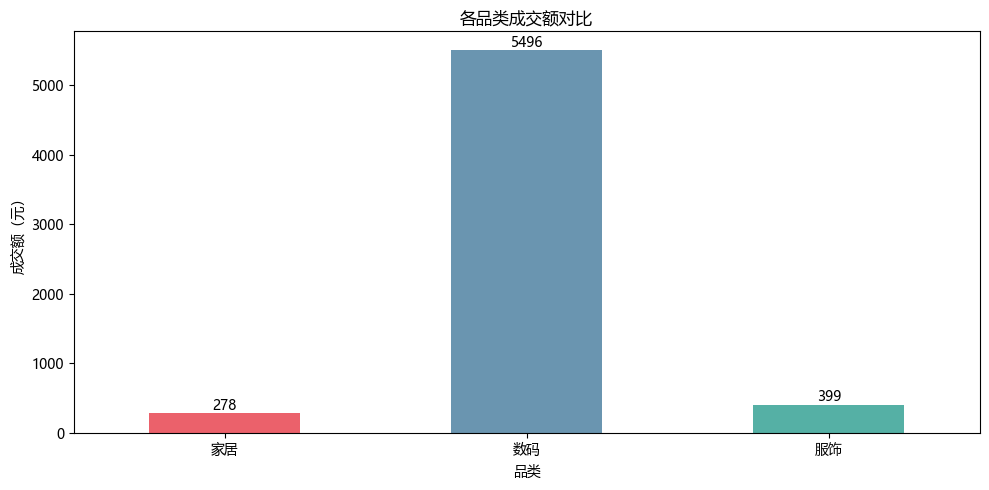

In [26]:
plt.figure(figsize=(10, 5))
category_analysis['实际成交额(元)'].plot(
    kind='bar',
    color=['#E63946', '#457B9D', '#2A9D8F'],
    alpha=0.8
)
plt.title('各品类成交额对比')
plt.xlabel('品类')
plt.ylabel('成交额（元）')
plt.xticks(rotation=0)

# 添加数值标签
for i, v in enumerate(category_analysis['实际成交额(元)']):
    plt.text(i, v+50, f'{v:.0f}', ha='center')
plt.tight_layout()
plt.show()

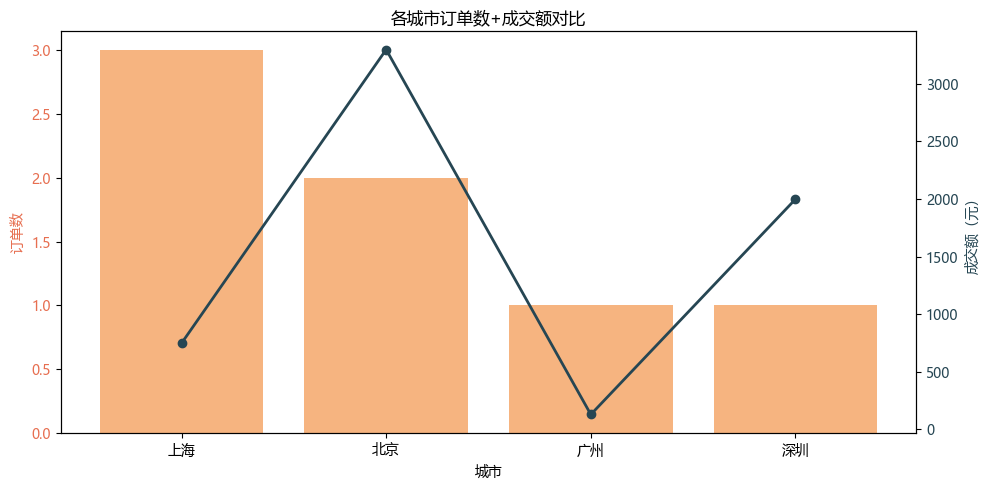

In [29]:
fig, ax1 = plt.subplots(figsize=(10, 5))
# 左轴：订单数
ax1.bar(city_analysis.index, city_analysis['订单数'], color='#F4A261', alpha=0.8)
ax1.set_xlabel('城市')
ax1.set_ylabel('订单数', color='#E76F51')
ax1.tick_params(axis='y', labelcolor='#E76F51')
# 右轴：成交额
ax2 = ax1.twinx()
ax2.plot(city_analysis.index, city_analysis['实际成交额(元)'], 'o-', color='#264653', linewidth=2)
ax2.set_ylabel('成交额（元）', color='#264653')
ax2.tick_params(axis='y', labelcolor='#264653')
plt.title('各城市订单数+成交额对比')

plt.tight_layout()
plt.show()

In [31]:
df_clean

,订单号,下单时间,支付时间,商品名称,品类,单价(元),数量,支付金额(元),退款金额(元),城市,用户ID,支付状态,实际成交额(元),利润(元),下单日期
0,ORD001,2024-05-01 08:30:00,2024-05-01 08:35:00,智能手机,数码,2999,1,2999,0.0,北京,U001,已支付,2999.0,599.8,2024-05-01
1,ORD002,2024-05-01 09:10:00,2024-05-02 09:12:00,无线耳机,数码,199,1,199,0.0,上海,U002,已支付,199.0,39.8,2024-05-01
4,ORD005,2024-05-02 14:00:00,2024-05-02 14:08:00,机械键盘,数码,299,1,299,0.0,北京,U005,已支付,299.0,59.8,2024-05-02
5,ORD006,2024-05-03 09:00:00,2024-05-03 09:10:00,运动跑鞋,服饰,399,1,399,0.0,上海,U006,已支付,399.0,79.8,2024-05-03
6,ORD007,2024-05-03 15:30:00,2024-05-03 15:35:00,厨房刀具,家居,129,1,129,0.0,广州,U007,已支付,129.0,25.8,2024-05-03
7,ORD008,2024-05-04 10:20:00,2024-05-04 10:22:00,平板电脑,数码,1999,1,1999,0.0,深圳,U008,已支付,1999.0,399.8,2024-05-04
9,ORD010,2024-05-05 11:00:00,2024-05-05 11:05:00,电饭煲,家居,299,1,299,149.5,上海,U010,已支付,149.5,29.9,2024-05-05


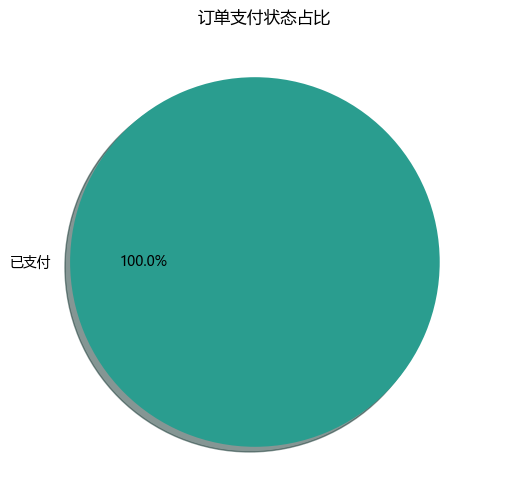

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# 统计支付状态
pay_status = df_clean['支付状态'].value_counts()

plt.figure(figsize=(8, 6))

# 自动生成 explode：只突出显示第一个分类（已支付）
explode = [0.05] + [0] * (len(pay_status) - 1)

# 自动配色（数量不够会循环使用）
colors = ['#2A9D8F', '#E63946', '#F4A261', '#E9C46A']

plt.pie(
    pay_status.values,
    labels=pay_status.index,
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,  # 现在长度自动匹配
    shadow=True
)
plt.title('订单支付状态占比')
plt.show()

In [33]:
df_clean.to_excel('清洗后订单数据.xlsx', index=False)
category_analysis.to_excel('品类分析结果.xlsx')